<a href="https://colab.research.google.com/github/lillymitch/organized_archives/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Loading

In [ ]:
## Data Loading
import pandas as pd
# Load dataset from MET Open Acess CSV
DATA_URL = "https://media.githubusercontent.com/media/metmuseum/openaccess/master/MetObjects.csv"

df = pd.read_csv(DATA_URL, low_memory=False)

# Keep only relevant columns (Object ID, Medium)
df = df[["Object ID", "Medium", ]]
# Remove missing or empty medium entries
df = df[df["Medium"].notna()]
df = df[df["Medium"].str.strip().str.lower() != ""]

# remove objects with no image
df = df[df["primaryImageSmall" or "primaryImage"].notna()]

medium_counts = df["Medium"].value_counts()
top_12_media = medium_counts.head(12).index.tolist()
print(f"Top 12 media identified: {top_12_media}")

df = df[df["Medium"].isin(top_12_media)] #filter based on top 12 mediums

print("Value counts after filtering by top 12 media:")
display(df["Medium"].value_counts())

Top 12 media identified: ['Terracotta', 'Commercial color lithograph', 'Etching', 'Engraving', 'Gelatin silver print', 'Albumen photograph', 'Silk', 'Bronze', 'Lithograph', 'Glass', 'Film negative', 'Faience']
Value counts after filtering by top 12 media:


,count
Medium,
Terracotta,23514
Commercial color lithograph,18206
Etching,17325
Engraving,11736
Gelatin silver print,10411
Albumen photograph,10152
Silk,8501
Bronze,7225
Lithograph,6987


## Data Preparation: Class Balancing

In [ ]:
## Class Balancing
# balance dataset so each medium has at most 300 samples
# prevents model from being biased towards dominant classes
filtered_df = (
  df.groupby("Medium", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 300), random_state=42))
    .reset_index(drop=True)
)

/tmp/ipykernel_56295/2496734428.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 300), random_state=42))


In [ ]:
print('Unique mediums and their counts in filtered_df:')
display(filtered_df['Medium'].value_counts())

Unique mediums and their counts in filtered_df:


,count
Medium,
Albumen photograph,300
Bronze,300
Commercial color lithograph,300
Engraving,300
Etching,300
Faience,300
Film negative,300
Gelatin silver print,300
Glass,300


## Data Preparation: Image Fetching

In [ ]:
## Image Fetching
# fetch image URLs from MET API using Object IDs
# Uses multithreading to speed up API calls
import time
import requests
from concurrent.futures import ThreadPoolExecutor

# fetch image urls
def get_image_url(object_id):
  object_url = f"https://collectionapi.metmuseum.org/public/collection/v1/objects/{object_id}"


  try:
    # Add a small delay to avoid rate limiting
    time.sleep(0.1) # Sleep for 100 milliseconds
    r = requests.get(object_url, timeout=5)
    r.raise_for_status()
    data = r.json()
    return data.get("primaryImageSmall") or data.get("primaryImage")

  except Exception as e:
    print(f"Error fetching image for object ID {object_id}: {e}")
    return None

print(get_image_url(25667))
# def fetch_image_urls(object_ids, max_workers=10):
#   with ThreadPoolExecutor(max_workers=max_workers) as executor:
#     return list(executor.map(get_image_url, object_ids))

# #call the function to fetch image URLs and add them to filtered_df
# if 'Object ID' in filtered_df.columns and 'Medium' in filtered_df.columns:
#     image_urls = get_image_urls(filtered_df["Object ID"].tolist())
#     filtered_df["image_url"] = image_urls
#     filtered_df = filtered_df[filtered_df["image_url"].notna() & (filtered_df["image_url"] != "")]
# else:
#     # This should ideally not be reached if previous cells executed correctly
#     # but added for robustness
#     print("Error: 'Object ID' or 'Medium' column not found in filtered_df. Please ensure previous data loading and balancing steps ran correctly.")

## Data Preparation: Label Encoding

In [ ]:
## Label Encoding
# convert medium labels (strings) into numeric class indices
# Required for training classification models
unique_media = filtered_df["Medium"].unique()
label_map = {medium: i for i, medium in enumerate(unique_media)}
filtered_df["label"] = filtered_df["Medium"].map(label_map)

## Data Preparation: Training Transforms

In [ ]:
## Training Transforms
from torchvision import transforms

train_processor = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_processor = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Custom Dataset Class Definition

In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import requests
from io import BytesIO

class MetDataset(Dataset):
  def __init__(self, df, transform=None):
    self.df = df.reset_index(drop=True)
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]

    url = row["image_url"]
    label = row["label"]

    try:
      r = requests.get(url, timeout=5)
      img = Image.open(BytesIO(r.content)).convert("RGB")

    except:
      img = Image.new("RGB", (224, 224))  # fallback image

    if self.transform:
      img = self.transform(img)

    return img, torch.tensor(label)

## Dataset Initialization and Example

In [ ]:
data = MetDataset(filtered_df, transform=train_processor)

# To correctly call __getitem__, use indexing:
img_example, label_example = data[0]

print(f"Type of image returned by __getitem__: {type(img_example)}")
print(f"Type of label returned by __getitem__: {type(label_example)}")
print(f"Shape of image tensor: {img_example.shape}")

Type of image returned by __getitem__: <class 'torch.Tensor'>
Type of label returned by __getitem__: <class 'torch.Tensor'>
Shape of image tensor: torch.Size([3, 224, 224])


## Data Splitting

In [ ]:
## Data Splitting
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(filtered_df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

train_dataset = MetDataset(train_df, transform=train_processor)
val_dataset = MetDataset(val_df, transform=test_processor)
test_dataset = MetDataset(test_df, transform=test_processor)

## Data Loaders

In [ ]:
## Data Loaders
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

## ResNet18 Transfer Learning

In [ ]:
## ResNet18 transfer learning
from torchvision import models
import torch.nn as nn

def build_transfer_model(num_classes):
  model = models.resnet18(pretrained=True)

  # freeze most layers
  for param in model.parameters():
    param.requires_grad = False

  # unfreeze last layer block (for better performance)
  for param in model.layer4.parameters():
    param.requires_grad = True

  # replace final layer
  model.fc = nn.Linear(model.fc.in_features, num_classes)

  return model

## Model Architecture: Logistic Regression

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Define a simple Logistic Regression model for image data
class LogisticRegression(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Input image is 3x224x224. Flatten to 3 * 224 * 224 features.
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(3 * 224 * 224, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        return self.linear(x)

# Define the cross-entropy loss function
def cross_entropy_loss(outputs, targets):
    return F.cross_entropy(outputs, targets)

## Optimizer Comparison Function

In [ ]:
def test_optimizer(model_builder_function, n_epochs=10):
    # num_classes, cross_entropy_loss, and train_loader are
    # expected to be available globally or passed in.

    small_alpha = 1e-6
    large_alpha = 2e-5

    optimizers_config = {
        "Gradient descent": {'lr': small_alpha, 'momentum': 0.0, 'optimizer_class': torch.optim.SGD},
        "Gradient descent (high learning rate)": {'lr': large_alpha, 'momentum': 0.0, 'optimizer_class': torch.optim.SGD},
        "Momentum": {'lr': small_alpha, 'momentum': 0.9, 'optimizer_class': torch.optim.SGD},
        "Momentum (high learning rate)": {'lr': large_alpha, 'momentum': 0.9, 'optimizer_class': torch.optim.SGD},
        "Adam": {'lr': small_alpha, 'optimizer_class': torch.optim.Adam},
        "Adam (high learning rate)": {'lr': large_alpha, 'optimizer_class': torch.optim.Adam},
    }

    losses_dict = {}

    for name, config in optimizers_config.items():
        # Re-initialize the model for each optimizer test to ensure a clean slate
        model = model_builder_function() # Build the model using the provided function

        # Create optimizer instance, passing model.parameters()
        optimizer_params = {'lr': config['lr']}
        if 'momentum' in config:
            optimizer_params['momentum'] = config['momentum']
        optimizer = config['optimizer_class'](model.parameters(), **optimizer_params)

        # Sanity check: print loss before first epoch
        model.eval()
        with torch.no_grad():

            total_loss = 0
            for images, labels in train_loader:
              y_pred = model(images)
              # Calculate loss
              loss = cross_entropy_loss(y_pred, labels)
              total_loss += loss.item() * images.size(0)
            avg_epoch_loss = total_loss / len(train_loader.dataset)
            print(f"Initial loss for {name}: {avg_epoch_loss}")


        losses_dict[name] = []
        losses_dict[name].append(avg_epoch_loss)
        for epoch in range(n_epochs):
            model.train()
            total_loss = 0
            # Iterate over the train_loader to get batches of images and labels
            for images, labels in train_loader:
                # Forward pass
                y_pred = model(images)
                # Calculate loss
                loss = cross_entropy_loss(y_pred, labels)

                # Backpropagation
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_loss += loss.item() * images.size(0) # Aggregate loss weighted by batch size

            avg_epoch_loss = total_loss / len(train_loader.dataset) # Average loss for the epoch
            losses_dict[name].append(avg_epoch_loss)

    fig, axarr = plt.subplots(1, 3, figsize = (12, 4), sharey=True)
    for name, losses in losses_dict.items():
        if "Gradient descent" in name:
            i = 0
        elif "Momentum" in name:
            i = 1
        else:
            i = 2

        if "high learning rate" in name:
            label = name.split(" ")[0] + " (high lr)"
            alpha_val = large_alpha
        else:
            label = name.split(" ")[0]
            alpha_val = small_alpha

        axarr[i].plot(losses, label=r"$\alpha = $" + f"{alpha_val:.0e}", linestyle = '-' if "high learning rate" in name else '--')
        axarr[i].set_title(name.split(" ")[0])
        if i == 2: # Only show legend on the last subplot
            axarr[i].legend()

        if i == 0:
            axarr[i].set_ylabel("Loss")
    for ax in axarr:
        ax.set_xlabel("Epoch")
        ax.grid(True)

    plt.suptitle("Training Loss for Different Optimizers")
    plt.tight_layout()
    plt.show()

## Training Loop Function

In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import requests
from io import BytesIO
#training loop
def train_model(model, train_loader, val_loader, optimizer,cross_entropy_loss, num_epochs = 1000):

  #GPU type
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  #load model to gpu
  model.to(device)
  #for debugging
  history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

  for epoch in range(num_epochs):
    model.train()

    total_train_loss = 0
    correct_train_predictions = 0
    total_train_elements = 0

    for images, labels in train_loader:

      #move images and labels to same gpuf
      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad() #prevents accumulating previous gradient values

      # Forward pass
      outputs = model(images)
      #params: predicted outputs(images) and true lables
      loss = cross_entropy_loss(outputs, labels)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      #aggregate loss, which is scaled by batch size
      total_train_loss += loss.item() * images.size(0)

      #finds max along dimension 1 (across classes)
      _, indices = torch.max(outputs, 1)

      #count how many predictions are correct
      correct_train_predictions += (indices == labels).sum().item()
      total_train_elements += labels.size(0)

    #training accuracy
    total_train_loss /= len(train_loader.dataset)

    #calculate accuracy
    train_accuracy = correct_train_predictions / total_train_elements
    history['train_loss'].append(total_train_loss)
    history['train_acc'].append(train_accuracy)
    print(train_accuracy)

    #repeat the same thing for validation data
    total_val_loss = 0
    correct_val_predictions = 0
    total_val_elements = 0

    #evaluating model (validation)
    model.eval()
    with torch.no_grad():
      for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        loss = cross_entropy_loss(outputs, labels)
        total_val_loss += loss.item() * images.size(0)

        _, indices = torch.max(outputs, 1)
        correct_val_predictions += (indices == labels).sum().item()
        total_val_elements += labels.size(0)

      #validation accuracy
      total_val_loss /= len(val_loader.dataset)
      val_accuracy = correct_val_predictions / total_val_elements
      history['val_loss'].append(total_val_loss)
      history['val_acc'].append(val_accuracy)
      print(val_accuracy)

## Main Execution Block

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s]


Initial loss for Gradient descent: 0.0
Initial loss for Gradient descent (high learning rate): 0.0
Initial loss for Momentum: 0.0
Initial loss for Momentum (high learning rate): 0.0
Initial loss for Adam: 0.0
Initial loss for Adam (high learning rate): 0.0


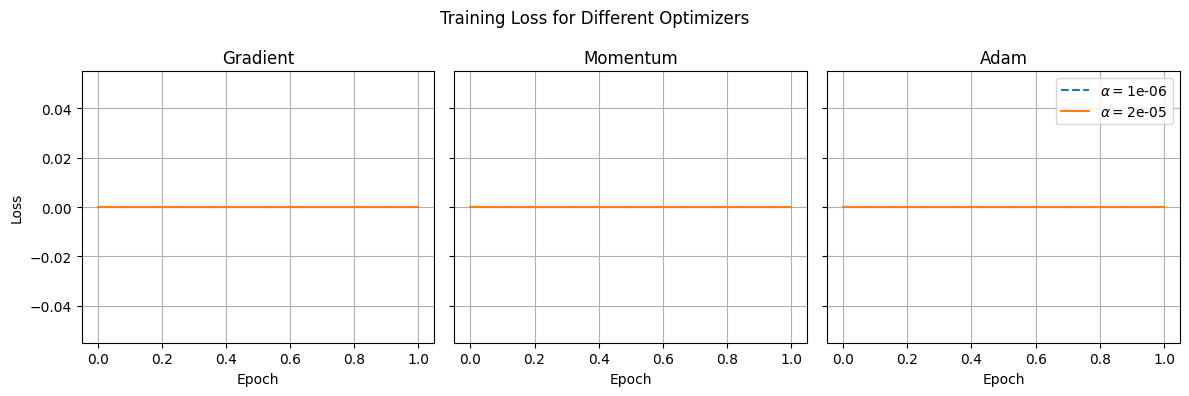

In [ ]:
model_builder_for_test = lambda: build_transfer_model(num_classes=len(label_map))

#first test optimizer to use
test_optimizer(model_builder_for_test, n_epochs=1)

In [ ]:
if __name__ == "__main__":
  num_classes = len(label_map)
  model = LogisticRegression(num_classes)